# ARIMA Time Series Forecasting for CPU Usage

This notebook demonstrates how to use the ARIMA model for univariate time series forecasting. We will:
- Load and inspect the feature-engineered dataset
- Preprocess the data for ARIMA
- Check for stationarity and apply differencing if needed
- Select ARIMA parameters (p, d, q)
- Fit the ARIMA model
- Forecast and evaluate performance
- (Optional) Use auto_arima for parameter selection

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Optional: Uncomment if you want to use auto_arima
# from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

## Load and Inspect Data
We will load the feature-engineered dataset and inspect the first few rows and basic statistics.

In [2]:
# Load the feature-engineered dataset
# We'll use the train/val/test splits for proper evaluation
train = pd.read_csv('../data/splits/train.csv', parse_dates=['date'])
val = pd.read_csv('../data/splits/val.csv', parse_dates=['date'])
test = pd.read_csv('../data/splits/test.csv', parse_dates=['date'])

print('Train shape:', train.shape)
print('Validation shape:', val.shape)
print('Test shape:', test.shape)

display(train.head())
display(train.describe())

Train shape: (708, 33)
Validation shape: (180, 33)
Test shape: (192, 33)


,date,region,resource_type,usage_cpu,usage_storage,users_active,econ_index,cloud_market_demand,holiday,day_of_week,...,storage_usage_rollmax_3,storage_usage_rollmin_3,cpu_usage_rollmean_7,cpu_usage_rollmax_7,cpu_usage_rollmin_7,storage_usage_rollmean_7,storage_usage_rollmax_7,storage_usage_rollmin_7,cpu_utilization_ratio,storage_efficiency
0,2023-01-01,eastus,Container,70,621,414,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707071,0.311278
1,2023-01-01,northeurope,Container,82,959,221,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.828283,0.485324
2,2023-01-01,northeurope,Storage,51,1715,476,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.520408,0.873218
3,2023-01-01,northeurope,VM,73,1937,493,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.737374,0.971414
4,2023-01-01,eastus,Storage,92,1595,388,104.97,0.99,True,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.929293,0.800703


,date,usage_cpu,usage_storage,users_active,econ_index,cloud_market_demand,day_of_week,month,quarter,is_weekend,...,storage_usage_rollmax_3,storage_usage_rollmin_3,cpu_usage_rollmean_7,cpu_usage_rollmax_7,cpu_usage_rollmin_7,storage_usage_rollmean_7,storage_usage_rollmax_7,storage_usage_rollmin_7,cpu_utilization_ratio,storage_efficiency
count,708,708.000000,708.000000,708.000000,708.000000,708.000000,708.000000,708.000000,708.0,708.000000,...,684.00000,684.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,708.000000,708.000000
mean,2023-01-30 00:00:00,74.936441,1251.706215,351.134181,98.535085,0.995763,2.966102,1.474576,1.0,0.288136,...,1621.52924,858.918129,75.113657,93.484277,55.844340,1243.311545,1799.199686,651.823899,0.757576,0.631853
min,2023-01-01 00:00:00,50.000000,500.000000,200.000000,73.800000,0.800000,0.000000,1.000000,1.0,0.000000,...,553.00000,500.000000,58.285714,69.000000,50.000000,688.142857,1023.000000,500.000000,0.505051,0.251254
25%,2023-01-15 00:00:00,62.000000,862.000000,280.750000,93.980000,0.940000,1.000000,1.000000,1.0,0.000000,...,1455.50000,590.000000,71.142857,90.750000,51.000000,1124.500000,1719.000000,533.000000,0.626263,0.437177
50%,2023-01-30 00:00:00,75.000000,1291.500000,350.500000,99.280000,0.990000,3.000000,1.000000,1.0,0.000000,...,1687.50000,790.000000,75.285714,96.000000,54.000000,1245.928571,1832.000000,589.000000,0.757576,0.652334
75%,2023-02-14 00:00:00,87.000000,1622.250000,426.000000,103.310000,1.050000,5.000000,2.000000,1.0,1.000000,...,1850.00000,1058.500000,79.321429,97.000000,59.000000,1372.428571,1934.000000,736.000000,0.887755,0.820793
max,2023-02-28 00:00:00,99.000000,1995.000000,499.000000,118.860000,1.250000,6.000000,2.000000,1.0,1.000000,...,1995.00000,1823.000000,90.142857,99.000000,75.000000,1710.142857,1995.000000,1543.000000,1.000000,1.000000
std,NaN,14.600098,440.175571,86.943854,8.569861,0.098363,2.043095,0.499706,0.0,0.453215,...,290.95893,311.090881,5.714503,5.375776,5.576891,175.254693,164.854246,159.984833,0.147612,0.222165


## Preprocess Data for ARIMA
We will select the univariate time series (CPU usage), handle missing values, and set the datetime index if needed.

In [4]:
# We'll focus on one region for univariate ARIMA (e.g., the region with most data)
region = train['region'].mode()[0]
print(f"Selected region for ARIMA: {region}")

# Filter for the selected region
train_region = train[train['region'] == region].copy()
val_region = val[val['region'] == region].copy()
test_region = test[test['region'] == region].copy()

# Group by date and aggregate (mean) to ensure unique dates
train_region = train_region.groupby('date', as_index=False).mean(numeric_only=True)
val_region = val_region.groupby('date', as_index=False).mean(numeric_only=True)
test_region = test_region.groupby('date', as_index=False).mean(numeric_only=True)

# Set date as index
train_region.set_index('date', inplace=True)
val_region.set_index('date', inplace=True)
test_region.set_index('date', inplace=True)

# Select the target column (CPU usage)
ts_train = train_region['usage_cpu'].asfreq('D')
ts_val = val_region['usage_cpu'].asfreq('D')
ts_test = test_region['usage_cpu'].asfreq('D')

# Handle missing values (if any)
ts_train = ts_train.fillna(method='ffill')
ts_val = ts_val.fillna(method='ffill')
ts_test = ts_test.fillna(method='ffill')

print(ts_train.head())

Selected region for ARIMA: eastus
date
2023-01-01    83.333333
2023-01-02    91.666667
2023-01-03    78.333333
2023-01-04    75.000000
2023-01-05    86.666667
Freq: D, Name: usage_cpu, dtype: float64


## Check Stationarity and Apply Differencing
Plot the time series and use the Augmented Dickey-Fuller test to check for stationarity. Apply differencing if needed.

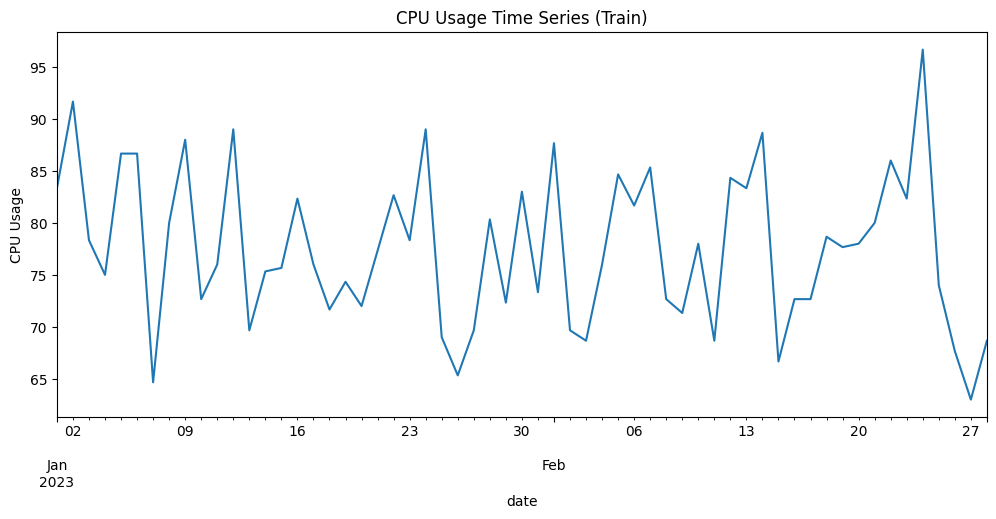

ADF Statistic: -5.408969
p-value: 0.000003
Critical Value 1%: -3.55770911573439
Critical Value 5%: -2.9167703434435808
Critical Value 10%: -2.59622219478738
Series is likely stationary.


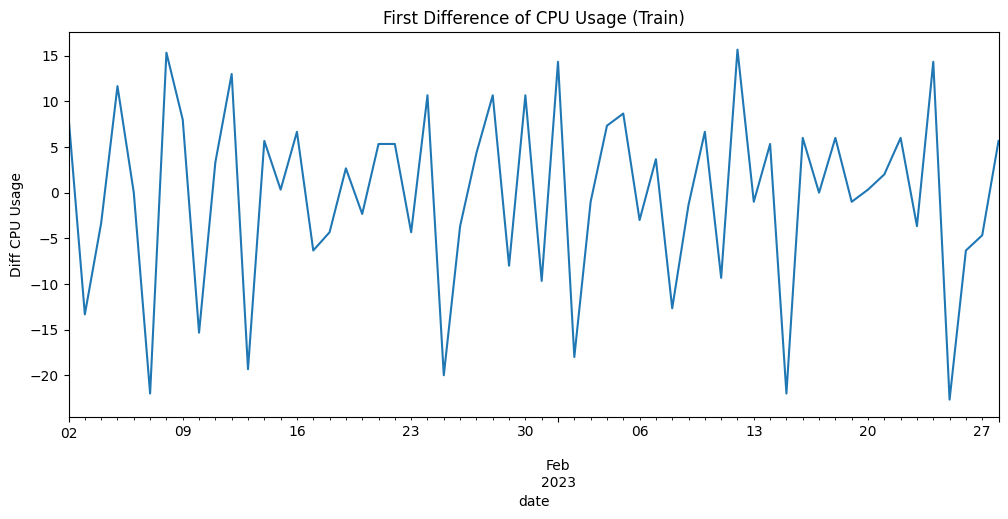

ADF Statistic: -5.383646
p-value: 0.000004
Critical Value 1%: -3.5656240522121956
Critical Value 5%: -2.920142229157715
Critical Value 10%: -2.598014675124952
Series is likely stationary.


In [5]:
# Plot the training time series
plt.figure(figsize=(12, 5))
ts_train.plot(title='CPU Usage Time Series (Train)', ylabel='CPU Usage')
plt.show()

# Augmented Dickey-Fuller test for stationarity
def adf_test(series):
    result = adfuller(series.dropna())
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    for key, value in result[4].items():
        print(f'Critical Value {key}: {value}')
    if result[1] < 0.05:
        print('Series is likely stationary.')
    else:
        print('Series is likely non-stationary.')

adf_test(ts_train)

# If non-stationary, try first differencing
ts_train_diff = ts_train.diff().dropna()
plt.figure(figsize=(12, 5))
ts_train_diff.plot(title='First Difference of CPU Usage (Train)', ylabel='Diff CPU Usage')
plt.show()
adf_test(ts_train_diff)

## Select ARIMA Parameters (p, d, q)
Use autocorrelation (ACF) and partial autocorrelation (PACF) plots to help select ARIMA parameters.

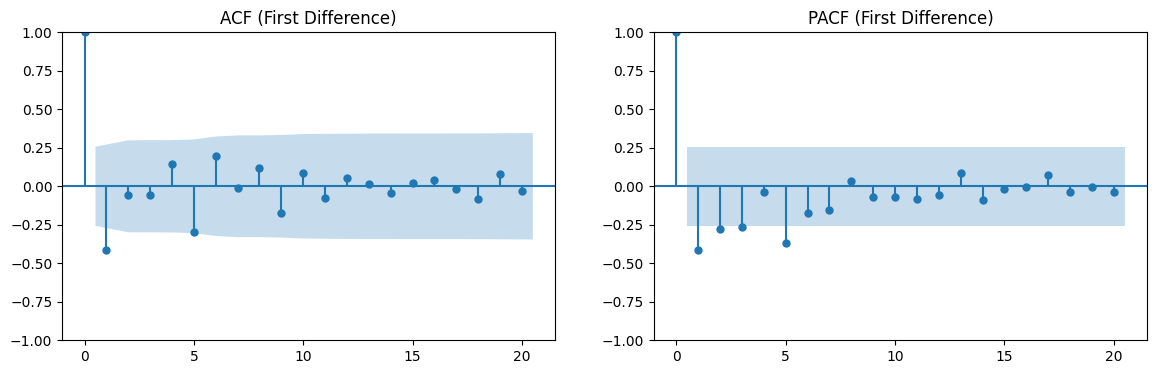

In [6]:
# Plot ACF and PACF for differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_train_diff, ax=axes[0], lags=20)
axes[0].set_title('ACF (First Difference)')
plot_pacf(ts_train_diff, ax=axes[1], lags=20)
axes[1].set_title('PACF (First Difference)')
plt.show()

# Based on plots, choose p, d, q (example: p=1, d=1, q=1)
p, d, q = 1, 1, 1

## Fit ARIMA Model
Fit the ARIMA model on the training set using the selected parameters and display the model summary.

In [7]:
# Fit ARIMA model
model = ARIMA(ts_train, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              usage_cpu   No. Observations:                   59
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -201.044
Date:                Mon, 22 Sep 2025   AIC                            408.088
Time:                        21:46:03   BIC                            414.269
Sample:                    01-01-2023   HQIC                           410.496
                         - 02-28-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1244      0.144      0.865      0.387      -0.157       0.406
ma.L1         -0.9998     16.136     -0.062      0.951     -32.627      30.627
sigma2        56.1950    902.750      0.062      0.9

## Forecast and Evaluate Performance
Generate forecasts on the validation set, calculate evaluation metrics (MAE, RMSE), and plot actual vs. predicted values.

Validation MAE: 7.58
Validation RMSE: 9.14


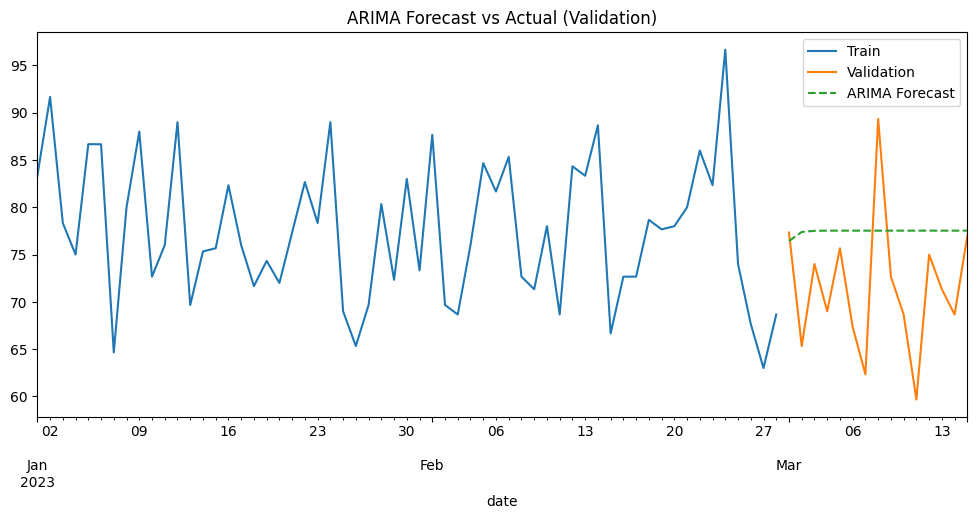

In [8]:
# Forecast for validation period
n_val = len(ts_val)
forecast = model_fit.forecast(steps=n_val)

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(ts_val, forecast)
rmse = np.sqrt(mean_squared_error(ts_val, forecast))
print(f"Validation MAE: {mae:.2f}")
print(f"Validation RMSE: {rmse:.2f}")

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
ts_train.plot(label='Train')
ts_val.plot(label='Validation')
plt.plot(ts_val.index, forecast, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Forecast vs Actual (Validation)')
plt.legend()
plt.show()

## Save the Trained ARIMA Model
Save the fitted ARIMA model for later use or deployment.

In [14]:
import joblib
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(model_fit, '../models/arima_model.pkl')
print('ARIMA model saved to models/arima_model.pkl')

ARIMA model saved to models/arima_model.pkl


## Additional Evaluation Metrics: MAPE and Forecast Bias
Calculate MAPE (Mean Absolute Percentage Error) and forecast bias for the ARIMA model on the test set.

In [11]:
# Forecast for test period
n_test = len(ts_test)
test_forecast = model_fit.forecast(steps=n_test)

# MAPE
mape = np.mean(np.abs((ts_test - test_forecast) / ts_test)) * 100
print(f"Test MAPE: {mape:.2f}%")

# Forecast Bias
bias = np.mean(test_forecast - ts_test)
print(f"Forecast Bias: {bias:.2f}")

Test MAPE: 7.34%
Forecast Bias: -6.14
